## Results from Rusterucci et al. (2026)

In this notebook you can provide input distances, absolute magnitudes, and physical half-light radii of dwarf galaxies and their expected detection probabilities in LSST will be returned.

For determining detection probabilities of individual dwarf galaxies, you can also check this [webpage](https://samuellimbo.github.io/samuelrusterucci/detect_prob_calculator.html).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

___
___

### Some definitions

In [281]:
#Opens Tables A1 through A6 from Rusterucci et al. (2026) 
table_dict = {}
for table_key in ['a1', 'a2', 'a3', 'a4', 'a5', 'a6']:
    table_dict[table_key] = pd.read_csv(f'./data/{table_key}.csv') 

#Defines the different distance bins, see Sect. 3.3 of Rusterucci et al. (2026)
distances_probed        = np.round(10**(np.linspace(1, 3, 7)), 1)

#Function for 50% recovery fraction (essentially Eq. A1 from Rusterucci et al. 2026)
def blended_parabolas(
        a, b, alpha, shift_r_h, shift_M_V):
    r_h_to_plot = np.linspace(0, 6, 100) #- final_best_parameters['shift_r_h']
    M_V_to_plot = a*((r_h_to_plot - shift_r_h)**2) + (b - a)*((r_h_to_plot - shift_r_h)**2)*(1/(1+np.exp(-alpha*(r_h_to_plot - shift_r_h)))) + shift_M_V

    return r_h_to_plot, M_V_to_plot

#This is Eq. A4 from Rusterucci et al. (2026)
def sigmoid_model(
    M_V, r_h, a, b, alpha, shift_M_V, shift_r_h, k1, k2, k3):
    x = r_h - shift_r_h

    h = a * x**2 + (b - a) * x**2 * (1 / (1 + np.exp(-alpha * x))) + shift_M_V

    h_prime_1 = 2 * a * x
    h_prime_2 = 2 * (b - a) * x / (1 + np.exp(-alpha * x))
    h_prime_3 = (b - a) * x**2 * (
        alpha * np.exp(-alpha * x) / (1 + np.exp(-alpha * x))**2
    )

    h_r_h_prime = h_prime_1 + h_prime_2 + h_prime_3

    k_r_h = k1 * x**2 + k2 * x + k3

    phi = ((M_V) - h) / np.sqrt(1 + h_r_h_prime**2)

    return 1 / (1 + np.exp(-k_r_h * phi))

___
___

### Your inputs

In [ ]:
#Distances (kpc)
input_dist = #10**np.random.uniform(1, 3, 10000)

#Absolute magnitudes
input_M_V = #np.random.uniform(-8, 2, 10000)

#Half-light radii (pc)
input_r_h = #10**np.random.uniform(1e-5, 3, 10000)

#Choose one photometric configuration: gr, ri, gri, ug, ugr, ugri
phot_config = 'gr'

___
___

### Finds the probabilities

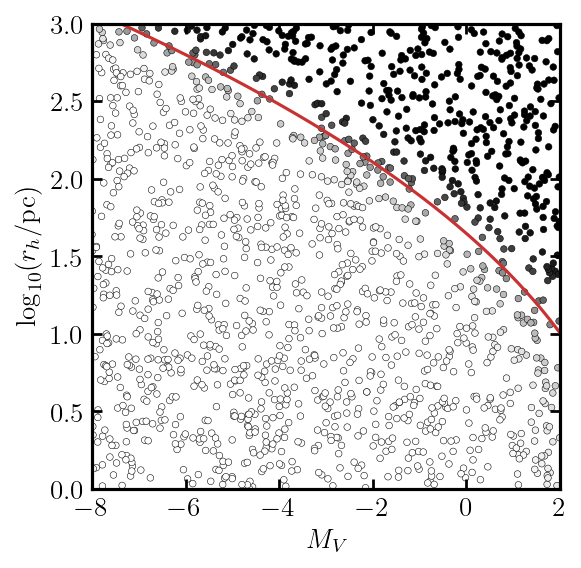

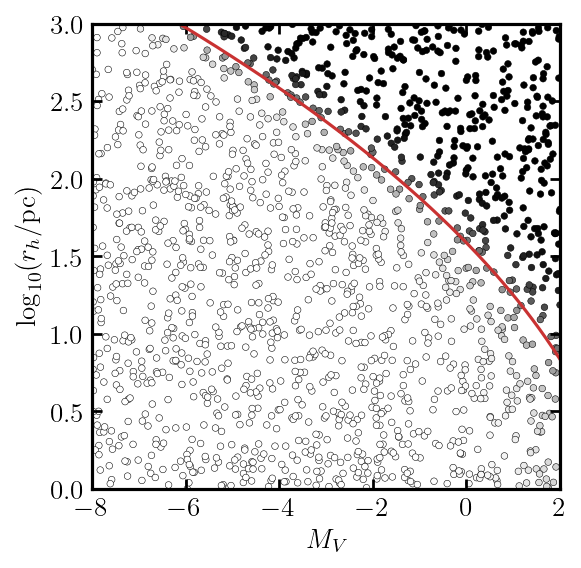

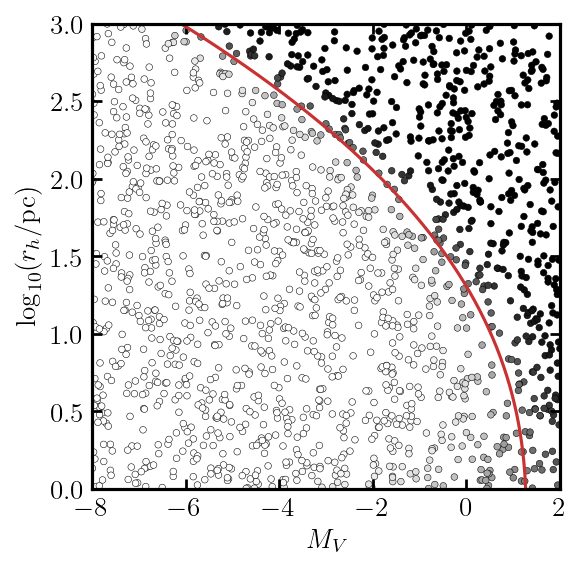

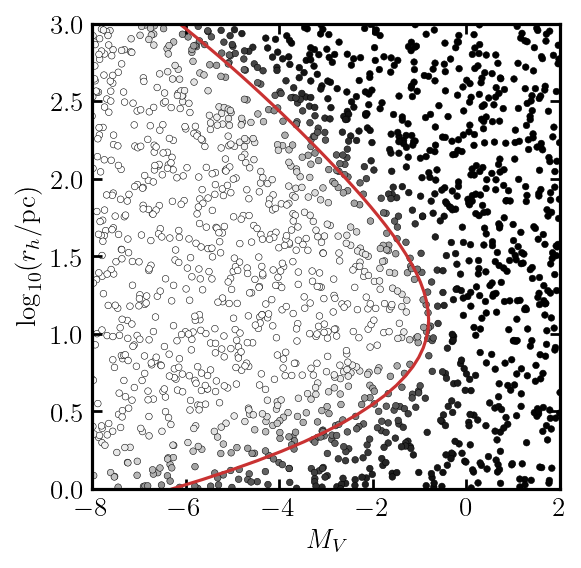

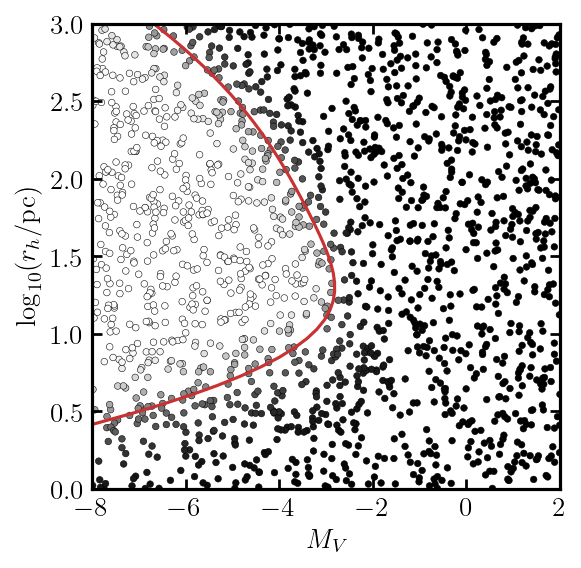

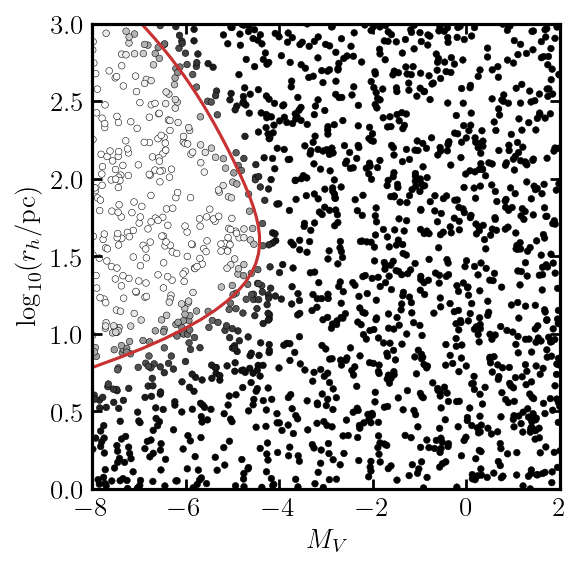

In [ ]:
#Computes the index of the distance bin for each dwarf galaxy
which_distance_bin = np.searchsorted(distances_probed, input_dist, side='left') - 1

#Initialises the detection probability array
detect_prob = np.zeros(len(input_dist))

for distance_bin in np.unique(which_distance_bin):
    #Selects the table corresponding to the correct distance bin
    temp_table = table_dict[list(table_dict.keys())[distance_bin]]

    #Selects the row corresponding to the chosen photometric configuration
    temp_table = temp_table[temp_table['config_name'] == phot_config]

    #Creates a temporary mask of the dwarfs within the current distance range
    temp_mask_dwarfs = (which_distance_bin == distance_bin)

    #Computes the values according to the 2D sigmoid
    current_probs = sigmoid_model(
        input_M_V[temp_mask_dwarfs], 
        np.log10(input_r_h[temp_mask_dwarfs]), 
        temp_table['a'].iloc[0], 
        temp_table['b'].iloc[0], 
        temp_table['alpha'].iloc[0], 
        temp_table['shift_M_V'].iloc[0], 
        temp_table['shift_r_h'].iloc[0], 
        temp_table['k1'].iloc[0], 
        temp_table['k2'].iloc[0], 
        temp_table['k3'].iloc[0]
    )

    #Adds the current probabilities to the final array
    detect_prob[temp_mask_dwarfs] = current_probs

    #Plot (comment the following if unnecessary)
    fig, ax = plt.subplots(figsize=(4,4), dpi=151)

    #Plots the input points and colours them
    ax.scatter(
        input_M_V[temp_mask_dwarfs], 
        np.log10(input_r_h[temp_mask_dwarfs]),
        c=current_probs, cmap='gray',
        s=10, linewidths=0.25, edgecolor='black'
    )

    #Calls the function to get the current distance 50% recovery fraction line
    r_h_to_plot, M_V_to_plot = blended_parabolas(
        temp_table['a'].iloc[0], 
        temp_table['b'].iloc[0], 
        temp_table['alpha'].iloc[0], 
        temp_table['shift_r_h'].iloc[0], 
        temp_table['shift_M_V'].iloc[0]
    )

    ax.plot(M_V_to_plot, r_h_to_plot, c="#C93232")

    ax.set_xlabel(r'$M_V$')
    ax.set_ylabel(r'$\log_{10}(r_h/\textrm{pc})$')
    ax.set_xlim(-8, 2)
    ax.set_ylim(0, 3)

    plt.show()

___
___

### Final probabilities (same shape as input)

In [284]:
detect_prob

array([2.76075724e-01, 1.07890259e-04, 4.63861837e-01, ...,
       1.06591326e-03, 4.65802868e-02, 9.46395638e-01])